# BEE 4750 Homework 1: Introduction to Using Julia

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\maozb\Documents\Cornell\BEE4750\Hw1\bee4750-hw1-maoz`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [3]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [4]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [ ]:
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1] # Problem 1.1: updated this line
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


1.1 Write-up:

The logical flaw in the code was that the initial minimum value was set to zero as a placeholder, and the loop does not correct for this placeholder. Therefore, if the array does not contain any negative numbers, then the loop will not update the placeholder zero with an actual value from the array, and will return the placeholder zero as the minumum value.
I solved this problem by using the first value in the array as a placeholder for the minumum value. This way, the loop will iterate through the array and only use values that are actually included in the array to determine the minimum value.

What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [17]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(grades) # Problem 1.2: changed this line
  return average_grade
end

average_grade = class_average(student_grades) # Problem 1.2: added this line
@show average_grade;

average_grade = 94.4


1.2 Write-up:

UndefVarError (undefined variable error) means that the variable average_grade is not defined. The code snippet returns an UndefVarError because average_grade is a variable defined inside the class_average function, but it is not defined as a variable outside of the function. The variable only exists inside the function but is not accessible directly without running the function.

Furthermore, inside the class_average function, the mean function calls the variable student_grades, which does not actually exist inside the function. It should instead take the mean of the "grades" input to the function.

To solve this error, I changed the code so that I am setting a variable average_grade equal to the output of the class_average function, so that this variable is actually defined before showing it. I also changed the average_grade line inside of the class_average function to take "grades" as an input since this is included in the function call.

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [20]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.374


1.3 Write-up:

The error is that "outcomes = zero(n_trials)" sets the variable outcomes equal to zero as an Int64 type, not as an array. Therefore, when the loop tries to set outcomes[i] equal to something, there results a MethodError because there is no setindex method for an integer since there is no index in an integer.

Changing the line to "outcomes = zeros(n_trials)" sets outcomes equal to an array of length n_trials, which makes it an iterable type which will have a setindex method.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [44]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    vect .-= m
    return vect
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [0.3530897588497647, -0.22233920762541215, -0.4285281431874265, 0.042094947473510835, -0.37439599509133203, 0.479195069788551, 0.3910893394555748, -0.4471088588956105, -0.029750755895614378, -0.07344137600461798, -0.18005114375283138, -0.4379018525699042, 0.10717834788822722, -0.4081569870718994, 0.3020299975497085, 0.371982984224829, 0.1455173742988366, 0.4311028567451851, 0.3525151872639247, -0.08887409254573819, -0.08267065359406245, 0.1540509526071312, 0.19501042894383747, -0.021791212037436947, -0.22090785146510228, 0.3059562613827772, -0.12324465967470521, -0.46753826304221857, 0.04737525523302222, -0.46508573619152627, 0.13611129421496004, 0.0804673153433676, 0.14519473572977215, -0.46312422925608454, 0.2906762514398844, -0.1945418265667732, 0.02378884572409523, -0.19407973849140558, 0.4070832732565244, -0.02025955343116448, -0.053430214025218525, -0.24332003096818422, 0.02498116786379001, -0.34306518673114617, -0.38767036179553804, -0.321324899667391,

1000-element Vector{Float64}:
  0.3530897588497647
 -0.22233920762541215
 -0.4285281431874265
  0.042094947473510835
 -0.37439599509133203
  0.479195069788551
  0.3910893394555748
 -0.4471088588956105
 -0.029750755895614378
 -0.07344137600461798
  ⋮
  0.022854558539040504
  0.22051538895596146
 -0.3971554491048144
 -0.04407972048258413
  0.19308111762076452
 -0.25416286330908266
 -0.24374977941622034
  0.3156914500557316
  0.39261319239309367

1.4 Write-up:

The MethodError in this case comes from attempting to subtract an integer from a vector (array) type object, which is not possible since they do not have the same number of items within them.

The solution to this error is to use "vect .-= m" which individually subtracts m from each element inside of the variable vect, instead of just attempting to subtract an integer from the entire vector as a whole.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

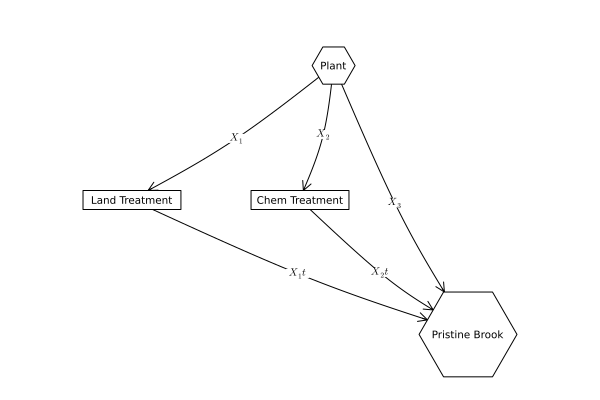

In [5]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"X_1", (1,3) => L"X_2", (1, 4) => L"X_3",(2, 4) => L"X_1t",(3, 4) => L"X_2t")
shapes=[:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names=names,edgelabel=edge_labels, markersize=0.15, markershapes=shapes, markercolor=:white, x=xpos, y=ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

2.1 Equations:

$X_1 + X_2 + X_3 = 100$ (Plant produces 100 m^3 of wastewater)

$X_1t = 0.2 * X_1$ (Output of land treatment)

$X_2t = (0.005*X_2) * X_2$ (Output of chemical treatment)

$W_d = X_1t + X_2t + X_3$ (Wastewater discharged into Pristine Brook)

$C = X_1^2 / 20 + 1.50 * X_2$ (Combined cost of treatment options)

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [ ]:
function multiple_return_values(x, y)
    return (x+y, x*y)
end

function yuk_discharge(x1, x2) # function for YUK discharge, x1 = diversion to land treatment, x2 = diversion to chemical treatment
    x3 = 100 - x1 - x2 # Plant produces 100 m^3 of wastewater
    x1t = 0.2 * x1 # Output of land treatment
    x2t = 0.005 * x2 * x2 # Output of chemical treatment
    wd = x1t + x2t + x3 # Wastewater discharged into Pristine Brook
    C = x1 * x1 / 20 + 1.5 * x2 # Combined cost of treatment options
    return(wd, C) # Returns wastewater discharge into the brook and cost
end

wd, C = yuk_discharge(10, 90)
@show wd;
@show C;

wd = 42.5
C = 140.0


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [ ]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = yuk_discharge.(x, y) # Changed to new YUK discharge function
wd = [out[1] for out in output] # Changed variable name to wd (wastewater discharged to brook)
c = [out[2] for out in output] # Changed variable name to c (cost)
@show wd;
@show c;

wd = [93.38, 91.645, 89.92, 88.205, 86.5]
c = [9.05, 10.7, 12.45, 14.3, 16.25]


2.3 Write-up:


I added a new function to use the equations from problem 2.1. The function takes waste diversion to land and chemical treatment options as input, and assumes the rest is untreated. The function uses the equations to solve for amount of polluted wastewater discharged to the Pristine Brook, and the cost of the given diversion plan.

Make sure you comment your code appropriately to make it clear what is
going on and why.

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

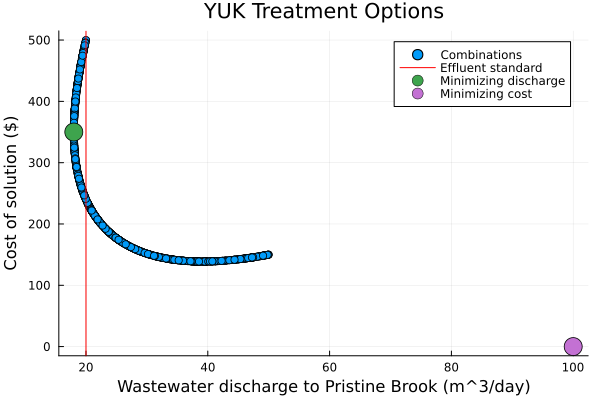

In [51]:
# Making the 1000 combinations with a Dirichlet distribution
d = Dirichlet([1,1])
samples = rand(d,1000) .* 100
pairs = permutedims(samples)

# Running YUK discharge function
results = [yuk_discharge(pairs[i,1], pairs[i,2]) for i in 1:size(pairs,1)]
wds = [r[1] for r in results]
cs = [r[2] for r in results]

# Plotting results
p = scatter(wds,cs,xlabel="Wastewater discharge to Pristine Brook (m^3/day)",ylabel="Cost of solution (\$)",label="Combinations",title="YUK Treatment Options")
vline!([20],color=:red,label="Effluent standard")
scatter!([18],[350],label="Minimizing discharge",markersize=10)
scatter!([100],[0],label="Minimizing cost",markersize=10)
display(p)

2.3 Write-up:

Yes, many of the solutions satisfy the YUK effluent standard! The minimum cost for a solution that satisfies this standard is around $240, which is not the cheapest but still relatively low compared to the high price of other solutions. There appears to be a tradeoff, where more effective solutions cost more, but there are also some relatively affordable solutions that do meet the standard.

I think that to find an optimal or better solution, there should be a "penalty" for any amount of wastewater discharge, since discharge would likely incur some sort of costs, financial, environmental, or otherwise. This would allow for a more robust model which would find a single optimal solution. In this case, however, I think that the optimal solution would the the cheapest one (~$240) which falls below the effluent standard. 

#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

The strategy to minimize cost would be to minimize the equation
$C = X_1^2 / 20 + 1.50 * X_2$ (Combined cost of treatment options).
This would result in an $X_1$ and an $X_2$ of zero, since discharging waste into the Brook is free.

The strategy to minimize YUK discharge would be to minimize the equations:

$X_1 + X_2 + X_3 = 100$ (Plant produces 100 m^3 of wastewater)

$X_1t = 0.2 * X_1$ (Output of land treatment)

$X_2t = (0.005*X_2) * X_2$ (Output of chemical treatment)

$W_d = X_1t + X_2t + X_3$ (Wastewater discharged into Pristine Brook)

This can be simplified:

$W_d = 0.2 * X_1 + 0.005 * X_2^2 + (100 - X_1 - X_2) = 100 - 0.8 * X_1 - X_2 + 0.005 * X_2^2$

Minimizing the equation, $W_d = 18 m^3/d$.

At this point, $X_1 = 80$ and $X_2 = 20$, and $X_3 = 0$ which was possible to predict beforehand since $X_3$ will always release more waste than $X_1$.

Therefore, cost is:

$C = X_1^2 / 20 + 1.50 * X_2 = (80^2)/20 + 1.50 * (20) = 350$.

This represents the left-most point on my graph, where waste is at a minimum but cost is somewhat high.

Personally, I would select the option around $240, since this is the cheapest way to avoid exceeding the YUK standard, assuming that there is no other incentive to further reduce discharge amount.



## References

List any external references consulted, including classmates.